In [137]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings(action='ignore')

In [138]:
X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_redundant=0,
    n_informative=5,
    n_clusters_per_class=1
)

In [139]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
df.shape

(100, 6)

In [140]:
df

,col1,col2,col3,col4,col5,target
0,2.215626,0.808702,-2.904901,-0.195663,0.756838,0
1,-4.045805,1.299310,1.426681,1.810528,1.142194,0
2,2.215164,0.454072,-2.157669,1.459829,0.653796,0
3,-2.569709,-1.058266,-0.676100,-2.267148,1.834279,1
4,0.422128,-1.426777,-2.959003,-0.380805,3.773069,1
...,...,...,...,...,...,...
95,1.349608,0.960254,-2.692537,-0.278492,-0.059173,0
96,-1.511046,0.562090,-2.049276,-1.119659,0.775136,0
97,-0.562025,1.282774,-0.399095,1.527407,2.149148,0
98,0.084226,1.173322,-1.620039,0.174093,0.584134,0


In [183]:
# Row sampling
def row_sampling(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [228]:
# Column sampling
def column_sampling(df, percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1]-1))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [229]:
# Combination sampling
def combination_sampling(df, row_percent, col_percent):
    sampled_rows = row_sampling(df, row_percent)
    return column_sampling(sampled_rows, col_percent)

In [230]:
# creating subsets of data by row sampling
df1 = row_sampling(df, 0.5)
df2 = row_sampling(df, 0.5)
df3 = row_sampling(df, 0.5)

In [231]:
df1.shape, df2.shape, df3.shape

((50, 6), (50, 6), (50, 6))

In [232]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# creating 3 base models
clf1 = clf2 = clf3 = DecisionTreeClassifier()
# trainig base models
clf1.fit(df1.drop(columns=['target']), df1['target'])
clf2.fit(df2.drop(columns=['target']), df2['target'])
clf3.fit(df3.drop(columns=['target']), df3['target'])

DecisionTreeClassifier()

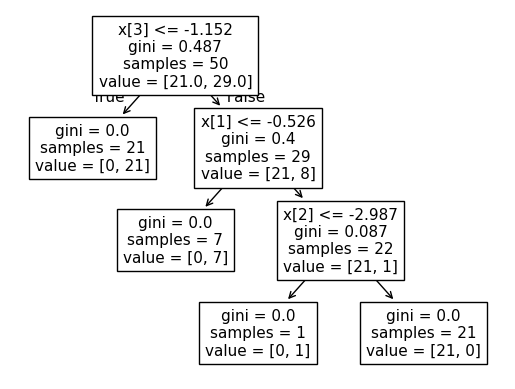

In [233]:
plot_tree(clf1)

plt.show()

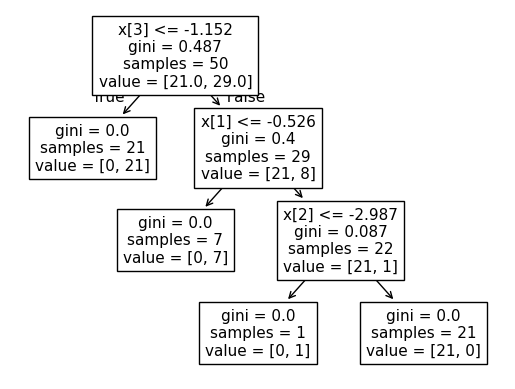

In [234]:
plot_tree(clf2)
plt.show()

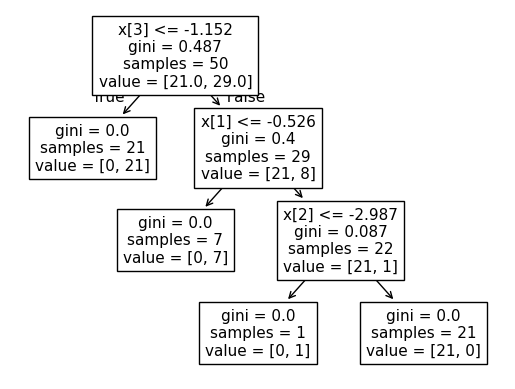

In [235]:
plot_tree(clf3)
plt.show()

In [236]:
clf1.predict(np.array([-2.252817, 4.236433, -2.162081, -2.909807, -0.480188]).reshape(1,-1))

array([1])

In [237]:
clf2.predict(np.array([-2.252817, 4.236433, -2.162081, -2.909807, -0.480188]).reshape(1,-1))

array([1])

In [238]:
clf3.predict(np.array([-2.252817, 4.236433, -2.162081, -2.909807, -0.480188]).reshape(1,-1))

array([1])

In [239]:
# creating subset of data using column sampling
df1 = column_sampling(df, 0.5)
df2 = column_sampling(df, 0.5)
df3 = column_sampling(df, 0.5)

In [240]:
# creating 3 base models
clf1 = clf2 = clf3 = DecisionTreeClassifier()
# trainig base models
clf1.fit(df1.drop(columns=['target']), df1['target'])
clf2.fit(df2.drop(columns=['target']), df2['target'])
clf3.fit(df3.drop(columns=['target']), df3['target'])

DecisionTreeClassifier()

In [251]:
combination_sampling(df, 0.5, 0.5)

,col2,col4,target
77,-4.473525,-0.090615,1
26,1.237802,1.232221,0
26,1.237802,1.232221,0
91,0.196647,-2.008575,1
9,0.377373,2.478453,0
1,1.299310,1.810528,0
11,-0.076998,-0.540836,1
7,1.708521,1.164261,0
91,0.196647,-2.008575,1
22,-1.047948,-1.761275,1
